In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

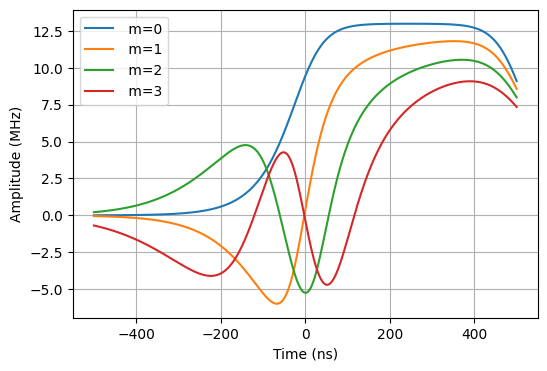

In [3]:
def f(t, m, kappa):
    return xi_m(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
t_vals = np.linspace(-500, 500, 501)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\qipe\AppData\Local\Temp\ipykernel_2104\1804629871.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_vals[i] = -np.trapz(integrand[:i+1], t_vals[:i+1])
C:\Users\qipe\AppData\Local\Temp\ipykernel_2104\1804629871.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f_1_out /= np.sqrt(np.trapz(np.abs(f_1_out)**2, t_vals))  # 正規化
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


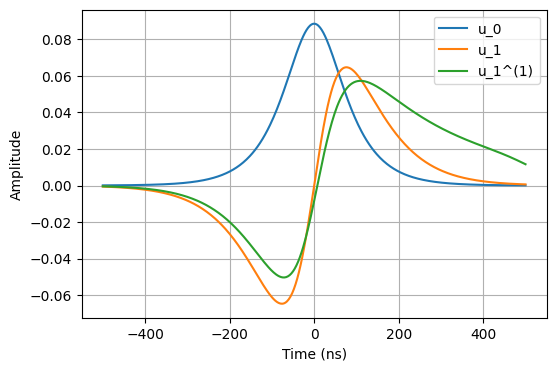

In [4]:
m0 = 0
m1 = 1

def f_1(t_vals, m0, m1, kappa_ph):
    f_m1_vals = f(t_vals, m1, kappa_ph)
    alpha_vals = np.zeros_like(t_vals, dtype=complex)
    g_vals_m0 = compute_g(t_vals, m0, kappa, kappa_ph)
    int_g2_m0 = cumulative_trapezoid(np.abs(g_vals_m0)**2, t_vals, initial=0)

    for i, t in enumerate(t_vals):
        # ∫_{-∞}^{t} g(t')u2(t') exp(1/2 ∫_{t'}^{t}|g(s)|^2 ds) dt'
        expo = np.exp(-0.5 * (int_g2_m0[i] - int_g2_m0))   # exp(∫_{t'}^t |g|^2 /2)
        integrand = g_vals_m0 * f_m1_vals * expo
        alpha_vals[i] = -np.trapz(integrand[:i+1], t_vals[:i+1])
    f_1_out = f_m1_vals - np.conjugate(g_vals_m0)*alpha_vals
    f_1_out /= np.sqrt(np.trapz(np.abs(f_1_out)**2, t_vals))  # 正規化
    return f_1_out
    
plt.figure(figsize=(6,4))
plt.plot(t_vals,  f(t_vals, m0, kappa_ph), label="u_0")
plt.plot(t_vals, f(t_vals, m1, kappa_ph), label="u_1")
plt.plot(t_vals, f_1(t_vals, m0, m1, kappa_ph), label="u_1^(1)")
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## QuTiP simulation

In [5]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
from analysis import (
    SpatiotemporalAnalysis,demodulate
)

### photon emission

In [6]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3
n_cutoff_vc1 = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vc1))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vc1))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc), qt.qeye(n_cutoff_vc1))
vc1 = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.destroy(n_cutoff_vc1))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vc1))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vc1))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vc1))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc), qt.qeye(n_cutoff_vc1))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 0))
vc1vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c0 = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a
H_c1 = 1j * (np.sqrt(kappa_r)/2) * vc1.dag()*a
H_c01 = 1j * (1/2) * vc1.dag() * vc#.dag()

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [7]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 501
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    # plt.plot(tgrid, cumint)
    # plt.show()
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    # plt.plot(tgrid, g_vals)
    # plt.ylim(-0.1, 0.2)
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

# mode for the first virtual cavity is 0`
g_u1_interps = []
for m in range(4):
    ut_vals = f_1(tgrid, 0, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-2
    denom = np.sqrt(1.0 - cumint + eps)
    # plt.plot(tgrid, cumint)
    g_vals = np.conjugate(ut_vals) / denom
    # plt.plot(tgrid, g_vals)
    # plt.ylim(-0.1, 0.2)
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u1_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    # print(args["g_u_interps"][m](t_local))
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_u1(t, args):
    m = int(args["input_num1"])
    t_local = float(t)
    # print(args["g_u1_interps"][m](t_local))
    return float(args["g_u1_interps"][m](t_local).real)

def g_u1_conj(t, args):
    return np.conjugate(g_u1(t, args))

def g_u10(t, args):
    m1 = int(args["input_num1"])
    m0 = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u1_interps"][m1](t_local)*np.conjugate(args["g_u_interps"][m0](t_local)))

def g_u10_conj(t, args):
    return np.conjugate(g_u10(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

C:\Users\qipe\AppData\Local\Temp\ipykernel_2104\1804629871.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_vals[i] = -np.trapz(integrand[:i+1], t_vals[:i+1])
C:\Users\qipe\AppData\Local\Temp\ipykernel_2104\1804629871.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f_1_out /= np.sqrt(np.trapz(np.abs(f_1_out)**2, t_vals))  # 正規化


c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


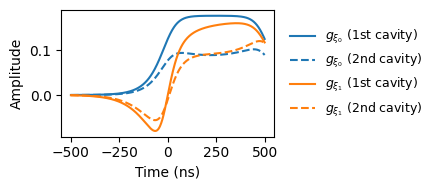

In [8]:
colors = ["tab:blue", "tab:orange"]
linestyles = ["-", "--"]

plt.figure(figsize=(4.5,2))
for i in range(2):
    plt.plot(
        t_vals,
        g_u_interps[i](t_vals),
        color=colors[i],
        linestyle=linestyles[0],
        lw=1.5,
        label=rf"$g_{{\xi_{i}}}$ (1st cavity)"
    )
    plt.plot(
        t_vals,
        g_u1_interps[i](t_vals),
        color=colors[i],
        linestyle=linestyles[1],
        lw=1.5,
        label=rf"$g_{{\xi_{i}}}$ (2nd cavity)"
    )
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y) where x>1 pushes outside
    frameon=False,
    fontsize=9,
)
plt.tight_layout()
plt.show()

In [ ]:
base_args = {
    "center": 0.0,
    "fogi_mode": 2,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}
results = {} 

for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj],
    ]
    psi0_m = (g0 + f0).unit()


    def total_c_op(t, args):
        c_op = np.sqrt(kappa_r) * a
        return c_op

    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_m = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_m, e_ops=e_ops,
        args=args_m, options=options, progress_bar=True
    )

    results[m] = result_m
    print(f"mode {m} finished")
# Extract states

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


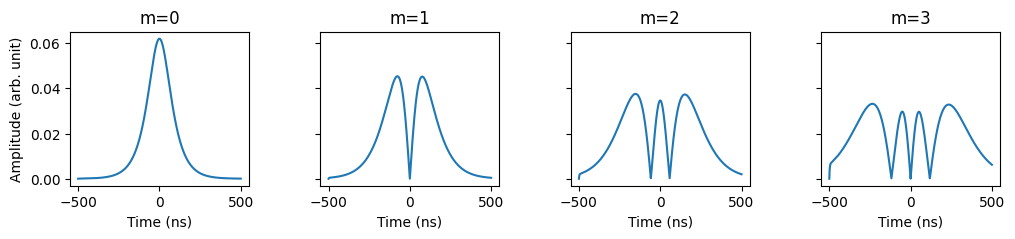

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(12, 2), sharey=True)
plt.subplots_adjust(wspace=0.4)

# Input operators
for i in range(4):
    states = results[i].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    vc1dvc1_s = qt.expect(vc1.dag() * vc1, states)
    vc1da_s = qt.expect(vc1.dag() * a, states)
    vcdvc1_s = qt.expect(vc.dag() * vc1, states)
    vc1dvc_s = qt.expect(vc1.dag() * vc, states)
    advc1_s = qt.expect(a.dag() * vc1, states)
    gu_values = np.array([g_u(t, base_args) for t in tgrid])
    # gu1_values = np.array([g_u(t, base_args1) for t in tgrid])
    LdL = (
        gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    axes[i].plot(tgrid, np.sqrt(LdL), label="photon waveform")
    axes[i].set_title(f"m={i}")
    axes[i].set_xlabel(r"Time (ns)")
    if i == 0:
        axes[i].set_ylabel("Amplitude (arb. unit)")
plt.show()

### photon absorption

mode 0 absorption

In [ ]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "g_u1_interps": g_u1_interps,
    "input_num": 0,
    "input_num1": 1,
    "input": 1,
}
vc1vc10 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 0))
vc0vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 1))
vc1vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 1))

results = {}

psi0_list_no_drive = {
    "vc1vc10": vc1vc10,
    "vc0vc11": vc0vc11,
    "vc1vc11": vc1vc11,
}

def total_c_op(t, args):
    c_op = np.conjugate(g_u(t, args)) * vc + np.conjugate(g_u1(t, args)) * vc1 + np.sqrt(kappa_r) * a
    return c_op

c_ops_n = [
    total_c_op,
    # np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
    # np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
]

H_m_no_drive = [
    H_fogi,
    [H_c0, g_u], [H_c0.dag(), g_u_conj],
    [H_c1, g_u1], [H_c1.dag(), g_u1_conj],
    [H_c01, g_u10], [H_c01.dag(), g_u10_conj],
]

for name, psi0_m in psi0_list_no_drive.items():
    result_n = qt.mesolve(
        H_m_no_drive, psi0_m, tgrid, c_ops_n,
        e_ops=e_ops, args=base_args, options=options, progress_bar=True
    )
    results[f"no_drive_{name}"] = result_n

args_drive = base_args.copy()
args_drive['fogi_mode'] = 0 

H_m_drive = [
    H_fogi,
    [H_c0, g_u], [H_c0.dag(), g_u_conj],
    [H_c1, g_u1], [H_c1.dag(), g_u1_conj],
    [H_c01, g_u10], [H_c01.dag(), g_u10_conj],
    [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
]

for name, psi0_m in psi0_list_no_drive.items():
    result_n = qt.mesolve(
        H_m_drive, psi0_m, tgrid, c_ops_n,
        e_ops=e_ops, args=args_drive, options=options, progress_bar=True
    )
    results[f"drive_{name}"] = result_n

C:\Users\qipe\AppData\Local\Temp\ipykernel_2104\2792644927.py:80: ComplexWarning: Casting complex values to real discards the imaginary part
  return float(args["g_u1_interps"][m1](t_local)*np.conjugate(args["g_u_interps"][m0](t_local)))


10.0%. Run time:   9.79s. Est. time left: 00:00:01:28
20.0%. Run time:  19.47s. Est. time left: 00:00:01:17
30.0%. Run time:  28.96s. Est. time left: 00:00:01:07
40.0%. Run time:  39.76s. Est. time left: 00:00:00:59
50.0%. Run time:  51.48s. Est. time left: 00:00:00:51
60.0%. Run time:  62.14s. Est. time left: 00:00:00:41
70.0%. Run time:  73.37s. Est. time left: 00:00:00:31
80.0%. Run time:  82.67s. Est. time left: 00:00:00:20
90.0%. Run time:  91.96s. Est. time left: 00:00:00:10
100.0%. Run time: 101.19s. Est. time left: 00:00:00:00
Total run time: 101.19s
10.0%. Run time:  10.83s. Est. time left: 00:00:01:37
20.0%. Run time:  20.78s. Est. time left: 00:00:01:23
30.0%. Run time:  30.53s. Est. time left: 00:00:01:11
40.0%. Run time:  40.25s. Est. time left: 00:00:01:00
50.0%. Run time:  50.37s. Est. time left: 00:00:00:50
60.0%. Run time:  59.72s. Est. time left: 00:00:00:39
70.0%. Run time:  69.15s. Est. time left: 00:00:00:29
80.0%. Run time:  78.46s. Est. time left: 00:00:00:19
90.

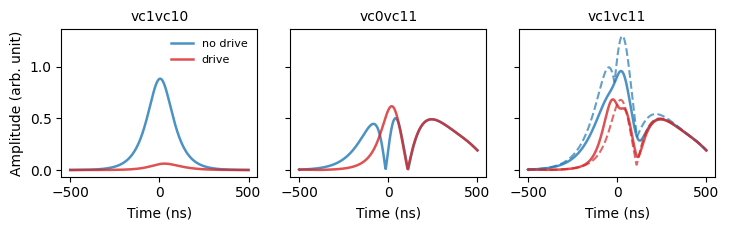

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.4), sharey=True)
plt.subplots_adjust(wspace=0.35)

init_states = ["vc1vc10", "vc0vc11", "vc1vc11"]
LdL_dict = {} 
for i, state_name in enumerate(init_states):
    ax = axes[i]
    
    for drive_state, color, label in [
        ("no_drive", "tab:blue", "no drive"),
        ("drive", "tab:red", "drive"),
    ]:
        key = f"{drive_state}_{state_name}"
        result = results[key]
        states = result.states

        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        vc1dvc1_s = qt.expect(vc1.dag() * vc1, states)
        vc1da_s = qt.expect(vc1.dag() * a, states)
        vcdvc1_s = qt.expect(vc.dag() * vc1, states)
        vc1dvc_s = qt.expect(vc1.dag() * vc, states)
        advc1_s = qt.expect(a.dag() * vc1, states)

        args_plot = {
            "center": 0.0,
            "fogi_mode": 0,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "g_u1_interps": g_u1_interps,
            "input_num": 0,
            "input_num1": 1,
            "input": 0,
        }

        gu_values = np.array([g_u(t, args_plot) for t in tgrid])
        gu1_values = np.array([g_u1(t, args_plot) for t in tgrid])

        LdL = (
            kappa_r * ada_s
            + np.sqrt(kappa_r) * (
                np.conjugate(gu_values) * advc_s
                + np.conjugate(gu1_values) * advc1_s
                + gu_values * vcda_s
                + gu1_values * vc1da_s
            )
            + (gu_values)**2 * vcdvc_s
            + gu_values * np.conjugate(gu1_values) * vcdvc1_s
            + gu1_values * np.conjugate(gu_values) * vc1dvc_s
            + (gu1_values)**2 * vc1dvc1_s
        )
        LdL_dict[key] = np.abs(np.sqrt(LdL)) * 1e1
        ax.plot(
            tgrid, np.abs(np.sqrt(LdL)) * 1e1,
            lw=1.8, alpha=0.8, color=color, label=label
        )

    ax.set_xlabel("Time (ns)")
    ax.set_title(state_name, fontsize=10)
    if i == 0:
        ax.set_ylabel("Amplitude (arb. unit)")
        ax.legend(frameon=False, fontsize=8)
ax3 = axes[2]
LdL_sum_no_drive = (LdL_dict["no_drive_vc1vc10"] + LdL_dict["no_drive_vc0vc11"]) 
LdL_sum_drive = (LdL_dict["drive_vc1vc10"] + LdL_dict["drive_vc0vc11"])

ax3.plot(tgrid, LdL_sum_no_drive, color="tab:blue", linestyle="--", lw=1.5, alpha=0.7, label="sum (no drive)")
ax3.plot(tgrid, LdL_sum_drive, color="tab:red", linestyle="--", lw=1.5, alpha=0.7, label="sum (drive)")
# ax3.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


In [28]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "g_u1_interps": g_u1_interps,
    "input_num": 0,
    "input_num1": 1,
    "input": 1,
}
vc1vc10 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 0))
vc0vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 1))
vc1vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 1))

results = {}

psi0_list_no_drive = {
    "vc1vc10": vc1vc10,
    "vc0vc11": vc0vc11,
    "vc1vc11": vc1vc11,
}

def total_c_op(t, args):
    c_op = np.conjugate(g_u(t, args)) * vc + np.conjugate(g_u1(t, args)) * vc1 + np.sqrt(kappa_r) * a
    return c_op

c_ops_n = [
    total_c_op,
    # np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
    # np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
]

H_m_no_drive = [
    H_fogi,
    [H_c0, g_u], [H_c0.dag(), g_u_conj],
    [H_c1, g_u1], [H_c1.dag(), g_u1_conj],
    [H_c01, g_u10], [H_c01.dag(), g_u10_conj],
]

for name, psi0_m in psi0_list_no_drive.items():
    result_n = qt.mesolve(
        H_m_no_drive, psi0_m, tgrid, c_ops_n,
        e_ops=e_ops, args=base_args, options=options, progress_bar=True
    )
    results[f"no_drive_{name}"] = result_n

args_drive = base_args.copy()
args_drive['fogi_mode'] = 1

H_m_drive = [
    H_fogi,
    [H_c0, g_u], [H_c0.dag(), g_u_conj],
    [H_c1, g_u1], [H_c1.dag(), g_u1_conj],
    [H_c01, g_u10], [H_c01.dag(), g_u10_conj],
    [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
]

for name, psi0_m in psi0_list_no_drive.items():
    result_n = qt.mesolve(
        H_m_drive, psi0_m, tgrid, c_ops_n,
        e_ops=e_ops, args=args_drive, options=options, progress_bar=True
    )
    results[f"drive_{name}"] = result_n

C:\Users\qipe\AppData\Local\Temp\ipykernel_2104\2792644927.py:80: ComplexWarning: Casting complex values to real discards the imaginary part
  return float(args["g_u1_interps"][m1](t_local)*np.conjugate(args["g_u_interps"][m0](t_local)))


10.0%. Run time:   1.11s. Est. time left: 00:00:00:09
20.0%. Run time:   2.20s. Est. time left: 00:00:00:08
30.0%. Run time:   3.09s. Est. time left: 00:00:00:07
40.0%. Run time:   3.93s. Est. time left: 00:00:00:05
50.0%. Run time:   4.77s. Est. time left: 00:00:00:04
60.0%. Run time:   5.65s. Est. time left: 00:00:00:03
70.0%. Run time:   6.63s. Est. time left: 00:00:00:02
80.0%. Run time:   7.51s. Est. time left: 00:00:00:01
90.0%. Run time:   8.40s. Est. time left: 00:00:00:00
100.0%. Run time:   9.35s. Est. time left: 00:00:00:00
Total run time:   9.35s
10.0%. Run time:   0.87s. Est. time left: 00:00:00:07
20.0%. Run time:   1.73s. Est. time left: 00:00:00:06
30.0%. Run time:   2.58s. Est. time left: 00:00:00:06
40.0%. Run time:   3.43s. Est. time left: 00:00:00:05
50.0%. Run time:   4.26s. Est. time left: 00:00:00:04
60.0%. Run time:   5.11s. Est. time left: 00:00:00:03
70.0%. Run time:   5.95s. Est. time left: 00:00:00:02
80.0%. Run time:   6.83s. Est. time left: 00:00:00:01
90.

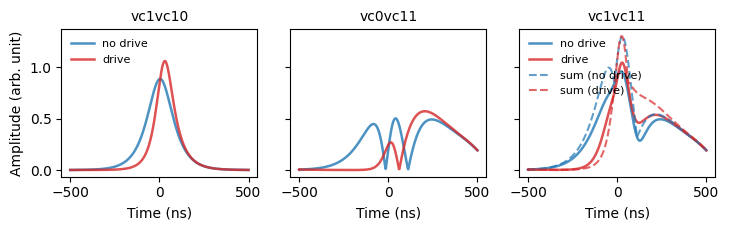

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.4), sharey=True)
plt.subplots_adjust(wspace=0.35)

init_states = ["vc1vc10", "vc0vc11", "vc1vc11"]
LdL_dict = {} 
for i, state_name in enumerate(init_states):
    ax = axes[i]
    
    for drive_state, color, label in [
        ("no_drive", "tab:blue", "no drive"),
        ("drive", "tab:red", "drive"),
    ]:
        key = f"{drive_state}_{state_name}"
        result = results[key]
        states = result.states

        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        vc1dvc1_s = qt.expect(vc1.dag() * vc1, states)
        vc1da_s = qt.expect(vc1.dag() * a, states)
        vcdvc1_s = qt.expect(vc.dag() * vc1, states)
        vc1dvc_s = qt.expect(vc1.dag() * vc, states)
        advc1_s = qt.expect(a.dag() * vc1, states)

        args_plot = {
            "center": 0.0,
            "fogi_mode": 0,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "g_u1_interps": g_u1_interps,
            "input_num": 0,
            "input_num1": 1,
            "input": 0,
        }

        gu_values = np.array([g_u(t, args_plot) for t in tgrid])
        gu1_values = np.array([g_u1(t, args_plot) for t in tgrid])

        LdL = (
            kappa_r * ada_s
            + np.sqrt(kappa_r) * (
                np.conjugate(gu_values) * advc_s
                + np.conjugate(gu1_values) * advc1_s
                + gu_values * vcda_s
                + gu1_values * vc1da_s
            )
            + (gu_values)**2 * vcdvc_s
            + gu_values * np.conjugate(gu1_values) * vcdvc1_s
            + gu1_values * np.conjugate(gu_values) * vc1dvc_s
            + (gu1_values)**2 * vc1dvc1_s
        )
        LdL_dict[key] = np.abs(np.sqrt(LdL)) * 1e1
        ax.plot(
            tgrid, np.abs(np.sqrt(LdL)) * 1e1,
            lw=1.8, alpha=0.8, color=color, label=label
        )

    ax.set_xlabel("Time (ns)")
    ax.set_title(state_name, fontsize=10)
    if i == 0:
        ax.set_ylabel("Amplitude (arb. unit)")
        ax.legend(frameon=False, fontsize=8)
ax3 = axes[2]
LdL_sum_no_drive = (LdL_dict["no_drive_vc1vc10"] + LdL_dict["no_drive_vc0vc11"]) 
LdL_sum_drive = (LdL_dict["drive_vc1vc10"] + LdL_dict["drive_vc0vc11"])

ax3.plot(tgrid, LdL_sum_no_drive, color="tab:blue", linestyle="--", lw=1.5, alpha=0.7, label="sum (no drive)")
ax3.plot(tgrid, LdL_sum_drive, color="tab:red", linestyle="--", lw=1.5, alpha=0.7, label="sum (drive)")
ax3.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


mode 1 absorption

In [188]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "g_u1_interps": g_u1_interps,
    "input_num": 0,
    "input_num1": 1,
    "input": 1,
}
vc1vc10 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 0))
vc0vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0), qt.basis(n_cutoff_vc1, 1))
vc1vc11 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1), qt.basis(n_cutoff_vc1, 1))

results1 = {}

psi0_list_no_drive = {
    "vc1vc10": vc1vc10,
    "vc0vc11": vc0vc11,
    "vc1vc11": vc1vc11,
}

H_m_no_drive = [
    H_fogi,
    [H_c0, g_u], [H_c0.dag(), g_u_conj],
    [H_c1, g_u1], [H_c1.dag(), g_u1_conj],
    [H_c1, g_u10], [H_c1.dag(), g_u10_conj],
]

for name, psi0_m in psi0_list_no_drive.items():
    result_n = qt.mesolve(
        H_m_no_drive, psi0_m, tgrid, c_ops_n,
        e_ops=e_ops, args=base_args, options=options, progress_bar=True
    )
    results1[f"no_drive_{name}"] = result_n

args_drive = base_args.copy()
args_drive['fogi_mode'] = 1 

H_m_drive = [
    H_fogi,
    [H_c0, g_u], [H_c0.dag(), g_u_conj],
    [H_c1, g_u1], [H_c1.dag(), g_u1_conj],
    [H_c1, g_u10], [H_c1.dag(), g_u10_conj],
    [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
]

for name, psi0_m in psi0_list_no_drive.items():
    result_n = qt.mesolve(
        H_m_drive, psi0_m, tgrid, c_ops_n,
        e_ops=e_ops, args=args_drive, options=options, progress_bar=True
    )
    results1[f"drive_{name}"] = result_n

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(
C:\Users\qipe\AppData\Local\Temp\ipykernel_28572\2715986887.py:86: ComplexWarning: Casting complex values to real discards the imaginary part
  return float(args["g_u1_interps"][m1](t_local)*np.conjugate(args["g_u_interps"][m0](t_local)))


10.0%. Run time:   9.56s. Est. time left: 00:00:01:26
20.0%. Run time:  18.79s. Est. time left: 00:00:01:15
30.0%. Run time:  28.13s. Est. time left: 00:00:01:05
40.0%. Run time:  37.51s. Est. time left: 00:00:00:56
50.0%. Run time:  46.86s. Est. time left: 00:00:00:46
60.0%. Run time:  56.24s. Est. time left: 00:00:00:37
70.0%. Run time:  65.47s. Est. time left: 00:00:00:28
80.0%. Run time:  74.92s. Est. time left: 00:00:00:18
90.0%. Run time:  84.32s. Est. time left: 00:00:00:09
100.0%. Run time:  93.47s. Est. time left: 00:00:00:00
Total run time:  93.47s
10.0%. Run time:  11.40s. Est. time left: 00:00:01:42
20.0%. Run time:  22.48s. Est. time left: 00:00:01:29
30.0%. Run time:  32.25s. Est. time left: 00:00:01:15
40.0%. Run time:  44.42s. Est. time left: 00:00:01:06
50.0%. Run time:  53.63s. Est. time left: 00:00:00:53
60.0%. Run time:  63.30s. Est. time left: 00:00:00:42
70.0%. Run time:  75.43s. Est. time left: 00:00:00:32
80.0%. Run time:  88.45s. Est. time left: 00:00:00:22
90.

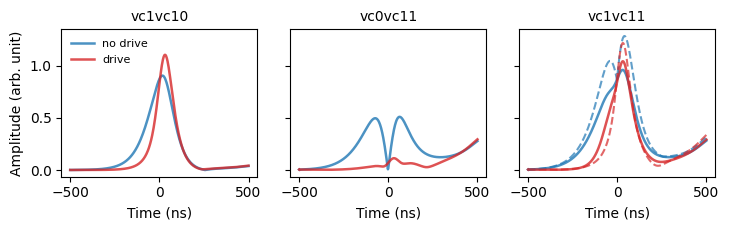

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.4), sharey=True)
plt.subplots_adjust(wspace=0.35)

init_states = ["vc1vc10", "vc0vc11", "vc1vc11"]
LdL_dict = {} 
for i, state_name in enumerate(init_states):
    ax = axes[i]
    
    for drive_state, color, label in [
        ("no_drive", "tab:blue", "no drive"),
        ("drive", "tab:red", "drive"),
    ]:
        key = f"{drive_state}_{state_name}"
        result = results1[key]
        states = result.states

        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        vc1dvc1_s = qt.expect(vc1.dag() * vc1, states)
        vc1da_s = qt.expect(vc1.dag() * a, states)
        vcdvc1_s = qt.expect(vc.dag() * vc1, states)
        vc1dvc_s = qt.expect(vc1.dag() * vc, states)
        advc1_s = qt.expect(a.dag() * vc1, states)

        args_plot = {
            "center": 0.0,
            "fogi_mode": 1,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "g_u1_interps": g_u1_interps,
            "input_num": 0,
            "input_num1": 1,
            "input": 0,
        }

        gu_values = np.array([g_u(t, args_plot) for t in tgrid])
        gu1_values = np.array([g_u1(t, args_plot) for t in tgrid])

        LdL = (
            kappa_r * ada_s
            + np.sqrt(kappa_r) * (
                np.conjugate(gu_values) * advc_s
                + np.conjugate(gu1_values) * advc1_s
                + gu_values * vcda_s
                + gu1_values * vc1da_s
            )
            + (gu_values)**2 * vcdvc_s
            + gu_values * np.conjugate(gu1_values) * vcdvc1_s
            + gu1_values * np.conjugate(gu_values) * vc1dvc_s
            + (gu1_values)**2 * vc1dvc1_s
        )
        LdL_dict[key] = np.abs(np.sqrt(LdL)) * 1e1
        ax.plot(
            tgrid, np.abs(np.sqrt(LdL)) * 1e1,
            lw=1.8, alpha=0.8, color=color, label=label
        )

    ax.set_xlabel("Time (ns)")
    ax.set_title(state_name, fontsize=10)
    if i == 0:
        ax.set_ylabel("Amplitude (arb. unit)")
        ax.legend(frameon=False, fontsize=8)
ax3 = axes[2]
LdL_sum_no_drive = (LdL_dict["no_drive_vc1vc10"] + LdL_dict["no_drive_vc0vc11"])
LdL_sum_drive = (LdL_dict["drive_vc1vc10"] + LdL_dict["drive_vc0vc11"])

ax3.plot(tgrid, LdL_sum_no_drive, color="tab:blue", linestyle="--", lw=1.5, alpha=0.7, label="sum (no drive)")
ax3.plot(tgrid, LdL_sum_drive, color="tab:red", linestyle="--", lw=1.5, alpha=0.7, label="sum (drive)")
# ax3.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()
